In [53]:
print("""In this notebook, I worked with a mushroom dataset to build a model that predicts whether a mushroom is edible or poisonous. The data includes 
22 categorical features like odor, gill size, cap shape, and more. I started by cleaning the data and using One-Hot Encoding to turn the categories into numbers. I trained a neural network using the full one-hot encoded data and got 100% accuracy on the test set. After that, I used PCA to reduce the 
number of features from 116 down to 60 while keeping 95% of the variance. I trained a second model on the PCA data and still got almost perfect results (just 2 total errors). Training time was a little faster with PCA, but not by much since the dataset is small and the model is simple. 
Overall, both models performed extremely well and showed that mushroom classification is highly predictable using this approach.
--Gilbert Morgan (DTSC-680)""")

In this notebook, I worked with a mushroom dataset to build a model that predicts whether a mushroom is edible or poisonous. The data includes 
22 categorical features like odor, gill size, cap shape, and more. I started by cleaning the data and using One-Hot Encoding to turn the categories into numbers. I trained a neural network using the full one-hot encoded data and got 100% accuracy on the test set. After that, I used PCA to reduce the 
number of features from 116 down to 60 while keeping 95% of the variance. I trained a second model on the PCA data and still got almost perfect results (just 2 total errors). Training time was a little faster with PCA, but not by much since the dataset is small and the model is simple. 
Overall, both models performed extremely well and showed that mushroom classification is highly predictable using this approach.
--Gilbert Morgan (DTSC-680)


In [2]:
import pandas as pd

# loading the dataset
csv_path = r'C:\Users\Eddie\Downloads\agaricus-lepiota (1).csv'
df = pd.read_csv(csv_path, header=None)

# showing the first few rows
df.head()

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
#PART 1 - Use the information provided in the .names file to properly assign column headers.

In [4]:
# reading the contents of .names
names_path = r'C:\Users\Eddie\Downloads\agaricus-lepiota (1).names'
with open(names_path, 'r') as file:
    names_content = file.readlines()

# previewing .names content to extract column names
names_content[:30]  # show the first 30 lines for review

['1. Title: Mushroom Database\n',
 '\n',
 '2. Sources: \n',
 '    (a) Mushroom records drawn from The Audubon Society Field Guide to North\n',
 '        American Mushrooms (1981). G. H. Lincoff (Pres.), New York: Alfred\n',
 '        A. Knopf\n',
 '    (b) Donor: Jeff Schlimmer (Jeffrey.Schlimmer@a.gp.cs.cmu.edu)\n',
 '    (c) Date: 27 April 1987\n',
 '\n',
 '3. Past Usage:\n',
 '    1. Schlimmer,J.S. (1987). Concept Acquisition Through Representational\n',
 '       Adjustment (Technical Report 87-19).  Doctoral disseration, Department\n',
 '       of Information and Computer Science, University of California, Irvine.\n',
 '       --- STAGGER: asymptoted to 95% classification accuracy after reviewing\n',
 '           1000 instances.\n',
 '    2. Iba,W., Wogulis,J., & Langley,P. (1988).  Trading off Simplicity\n',
 '       and Coverage in Incremental Concept Learning. In Proceedings of \n',
 '       the 5th International Conference on Machine Learning, 73-79.\n',
 '       Ann Arbor, Mic

In [5]:
# printing more for attribute names
for i, line in enumerate(names_content[30:100], start=30):
    print(f"{i}: {line.strip()}")

30: crisp logical rules using constrained backpropagation networks -
31: comparison of two new approaches, in: Proc. of the European Symposium
32: on Artificial Neural Networks (ESANN'97), Bruge, Belgium 16-18.4.1997,
33: pp. xx-xx
34: 
35: Wlodzislaw Duch, Department of Computer Methods, Nicholas Copernicus
36: University, 87-100 Torun, Grudziadzka 5, Poland
37: e-mail: duch@phys.uni.torun.pl
38: WWW     http://www.phys.uni.torun.pl/kmk/
39: 
40: Date: Mon, 17 Feb 1997 13:47:40 +0100
41: From: Wlodzislaw Duch <duch@phys.uni.torun.pl>
42: Organization: Dept. of Computer Methods, UMK
43: 
44: I have attached a file containing logical rules for mushrooms.
45: It should be helpful for other people since only in the last year I
46: have seen about 10 papers analyzing this dataset and obtaining quite
47: complex rules. We will try to contribute other results later.
48: 
49: With best regards, Wlodek Duch
50: ________________________________________________________________
51: 
52: Logical r

In [6]:
# printing more to find the information I need
for i, line in enumerate(names_content[99:150], start=99):
    print(f"{i}: {line.strip()}")


99: three, let it be'' for Poisonous Oak and Ivy.
100: 
101: 5. Number of Instances: 8124
102: 
103: 6. Number of Attributes: 22 (all nominally valued)
104: 
105: 7. Attribute Information: (classes: edible=e, poisonous=p)
106: 1. cap-shape:                bell=b,conical=c,convex=x,flat=f,
107: knobbed=k,sunken=s
108: 2. cap-surface:              fibrous=f,grooves=g,scaly=y,smooth=s
109: 3. cap-color:                brown=n,buff=b,cinnamon=c,gray=g,green=r,
110: pink=p,purple=u,red=e,white=w,yellow=y
111: 4. bruises?:                 bruises=t,no=f
112: 5. odor:                     almond=a,anise=l,creosote=c,fishy=y,foul=f,
113: musty=m,none=n,pungent=p,spicy=s
114: 6. gill-attachment:          attached=a,descending=d,free=f,notched=n
115: 7. gill-spacing:             close=c,crowded=w,distant=d
116: 8. gill-size:                broad=b,narrow=n
117: 9. gill-color:               black=k,brown=n,buff=b,chocolate=h,gray=g,
118: green=r,orange=o,pink=p,purple=u,red=e,
119: white=w,yellow=

In [55]:
# The list of mushroom attributes starts around line 105 in the .names file.
# According to the file, the dataset contains 22 descriptive features (such as cap shape, color, odor, etc.),
# and the first column represents the target classification and whether each mushroom is edible ('e') or poisonous ('p').


In [8]:
# assign column for the .names file
columns = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring", "stalk-surface-below-ring",
    "stalk-color-above-ring", "stalk-color-below-ring", "veil-type", "veil-color",
    "ring-number", "ring-type", "spore-print-color", "population", "habitat"
]

# column names
df.columns = columns

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [9]:
#PART 2 - Split the data. 80% of the data should be for training and 20% should be for testing. 

In [10]:
from sklearn.model_selection import train_test_split

# splitting features (X) and labels (y)
X = df.drop("class", axis=1)     # all columns except 'class' go into X
y = df["class"]                  # target is the 'class' column

# 80/20 split for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,              # 20% for testing
    random_state=42,            # keeping it consistent
    stratify=y                  # keeps class distribution balanced
)

# shapes of the results
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)


Training features shape: (6499, 22)
Testing features shape: (1625, 22)
Training labels shape: (6499,)
Testing labels shape: (1625,)


In [11]:
#PART 3 - One-Hot Encode the features and Label Encode the responses of the training data.

In [12]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# one-hot encode the categorical features
encoder = OneHotEncoder(handle_unknown='ignore')

# fit on training data and convert to dense
X_train_encoded = encoder.fit_transform(X_train).toarray()
X_test_encoded = encoder.transform(X_test).toarray()

# label encode the class labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# check shapes
print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)
print("y_train_encoded shape:", y_train_encoded.shape)
print("y_test_encoded shape:", y_test_encoded.shape)


X_train_encoded shape: (6499, 116)
X_test_encoded shape: (1625, 116)
y_train_encoded shape: (6499,)
y_test_encoded shape: (1625,)


In [13]:
#Part 4 - Create a sequential neural network model for prediction on this data with two layers: an input layer and an output layer.

In [29]:
%%time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# create the model
model = Sequential()

# input layer (units can be tuned)
model.add(Dense(units=16, activation='relu', input_dim=X_train_encoded.shape[1]))

# output layer (1 neuron for binary classification)
model.add(Dense(units=1, activation='sigmoid'))

# compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# training block
history = model.fit(
    X_train_encoded, y_train_encoded,
    epochs=14,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/14
163/163 [==============================] - 1s 3ms/step - loss: 0.3491 - accuracy: 0.8782 - val_loss: 0.1310 - val_accuracy: 0.9785
Epoch 2/14
163/163 [==============================] - 0s 2ms/step - loss: 0.0801 - accuracy: 0.9862 - val_loss: 0.0504 - val_accuracy: 0.9885
Epoch 3/14
163/163 [==============================] - 0s 2ms/step - loss: 0.0359 - accuracy: 0.9956 - val_loss: 0.0273 - val_accuracy: 0.9985
Epoch 4/14
163/163 [==============================] - 0s 2ms/step - loss: 0.0205 - accuracy: 0.9979 - val_loss: 0.0184 - val_accuracy: 0.9985
Epoch 5/14
163/163 [==============================] - 0s 2ms/step - loss: 0.0132 - accuracy: 0.9992 - val_loss: 0.0115 - val_accuracy: 1.0000
Epoch 6/14
163/163 [==============================] - 0s 2ms/step - loss: 0.0091 - accuracy: 0.9994 - val_loss: 0.0082 - val_accuracy: 1.0000
Epoch 7/14
163/163 [==============================] - 0s 2ms/step - loss: 0.0066 - accuracy: 0.9998 - val_loss: 0.0062 - val_accuracy: 1.0000
Epoch 

In [14]:
#PART 5 - Train the model using the training data. Use the magic command %%time to time how long it takes to complete training 

In [33]:
%%time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# create the model
model = Sequential()
model.add(Dense(units=16, activation='relu', input_dim=X_train_encoded.shape[1]))
model.add(Dense(units=1, activation='sigmoid'))

# compile model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# train model
history = model.fit(
    X_train_encoded, y_train_encoded,
    epochs=13,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/13
163/163 [==============================] - 1s 3ms/step - loss: 0.3336 - accuracy: 0.8932 - val_loss: 0.1213 - val_accuracy: 0.9715
Epoch 2/13
163/163 [==============================] - 0s 2ms/step - loss: 0.0723 - accuracy: 0.9865 - val_loss: 0.0457 - val_accuracy: 0.9923
Epoch 3/13
163/163 [==============================] - 0s 2ms/step - loss: 0.0317 - accuracy: 0.9960 - val_loss: 0.0245 - val_accuracy: 0.9977
Epoch 4/13
163/163 [==============================] - 0s 2ms/step - loss: 0.0178 - accuracy: 0.9983 - val_loss: 0.0152 - val_accuracy: 0.9985
Epoch 5/13
163/163 [==============================] - 0s 2ms/step - loss: 0.0112 - accuracy: 0.9990 - val_loss: 0.0108 - val_accuracy: 0.9985
Epoch 6/13
163/163 [==============================] - 0s 2ms/step - loss: 0.0078 - accuracy: 1.0000 - val_loss: 0.0074 - val_accuracy: 1.0000
Epoch 7/13
163/163 [==============================] - 0s 2ms/step - loss: 0.0056 - accuracy: 0.9998 - val_loss: 0.0056 - val_accuracy: 1.0000
Epoch 

In [ ]:
#PART 6 - Use a Scikit Learn's ConfusionMatrixDisplay to analyze the results of the network.

✅ Making predictions on test set...
51/51 [==============================] - 0s 2ms/step
✅✅ Creating confusion matrix...


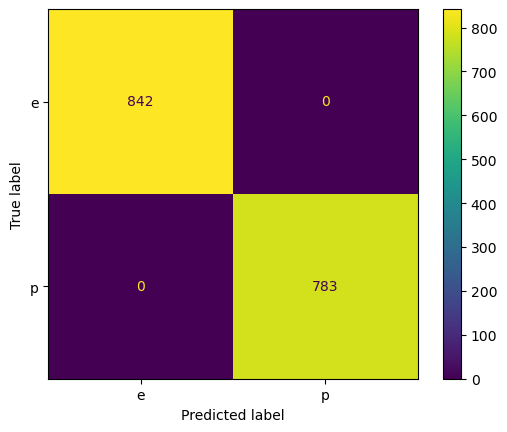

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# predict on test set
print("✅ Making predictions on test set...")
y_pred_probs = model.predict(X_test_encoded)

# convert probabilities to class labels
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# create confusion matrix
print("✅✅ Creating confusion matrix...")
cm = confusion_matrix(y_test_encoded, y_pred)

# display matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()

In [36]:
#PART 7 - Perform dimensionality reduction using PCA and keep 95% of the variance

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# scale the one-hot encoded features
print("Scaling encoded features")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# apply PCA to keep 95% of variance
print("Applying PCA (keep 95% variance)")
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# show result
print("Original features:", X_train_encoded.shape[1])
print("Features after PCA:", X_train_pca.shape[1])


Scaling encoded features
Applying PCA (keep 95% variance)
Original features: 116
Features after PCA: 60


In [40]:
#PART 8 - Create and train a new neural network on the PCA’ed data. Use the %%time command during training

In [39]:
%%time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# create the model for PCA input
model_pca = Sequential()
model_pca.add(Dense(units=16, activation='relu', input_dim=X_train_pca.shape[1]))
model_pca.add(Dense(units=1, activation='sigmoid'))

# compile the model
model_pca.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# train the model
history_pca = model_pca.fit(
    X_train_pca, y_train_encoded,
    epochs=12,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/12
163/163 [==============================] - 1s 2ms/step - loss: 0.5738 - accuracy: 0.7196 - val_loss: 0.2500 - val_accuracy: 0.9577
Epoch 2/12
163/163 [==============================] - 0s 2ms/step - loss: 0.1401 - accuracy: 0.9848 - val_loss: 0.0723 - val_accuracy: 0.9985
Epoch 3/12
163/163 [==============================] - 0s 2ms/step - loss: 0.0470 - accuracy: 0.9988 - val_loss: 0.0313 - val_accuracy: 0.9992
Epoch 4/12
163/163 [==============================] - 0s 2ms/step - loss: 0.0226 - accuracy: 0.9998 - val_loss: 0.0174 - val_accuracy: 0.9992
Epoch 5/12
163/163 [==============================] - 0s 2ms/step - loss: 0.0134 - accuracy: 0.9998 - val_loss: 0.0111 - val_accuracy: 1.0000
Epoch 6/12
163/163 [==============================] - 0s 2ms/step - loss: 0.0089 - accuracy: 0.9998 - val_loss: 0.0077 - val_accuracy: 1.0000
Epoch 7/12
163/163 [==============================] - 0s 2ms/step - loss: 0.0064 - accuracy: 0.9998 - val_loss: 0.0056 - val_accuracy: 1.0000
Epoch 

In [ ]:
#PART 9 - Use Scikit Learn's ConfuctionMatrixDisplay to analyze the results of the new network

Making predictions with PCA model...
51/51 [==============================] - 0s 970us/step
Building confusion matrix for PCA model...


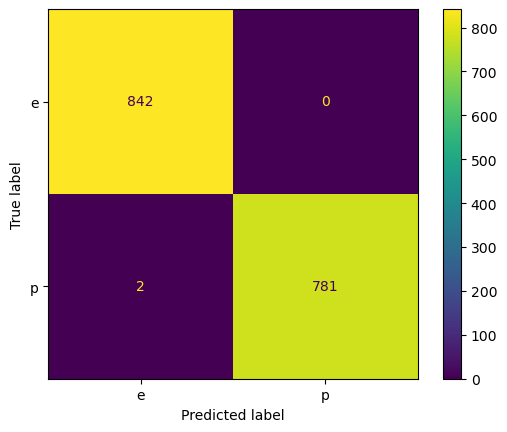

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# predict using PCA-based model
print("Making predictions with PCA model...")
y_pred_probs_pca = model_pca.predict(X_test_pca)

# convert probabilities to class labels (0 or 1)
y_pred_pca = (y_pred_probs_pca > 0.5).astype(int).flatten()

# build the confusion matrix
print("Building confusion matrix for PCA model...")
cm_pca = confusion_matrix(y_test_encoded, y_pred_pca)

# display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=label_encoder.classes_)
disp.plot()


In [ ]:
#PART 10A - How many features does the data have after the One-Hot Encoding? 
#How does this compare to the number of features that the data had before the encoding?

In [ ]:
#Before encoding, the dataset had 22 features. After One-Hot Encoding, it expanded to 116 features.

#The increase comes from splitting each category in a column into separate binary columns. This happens for all categorical features.

In [ ]:
#PART 10B - What should the units parameter of the output layer in the network be and why?

In [ ]:
#The units parameter should be set to 1 because this is a binary classification problem. 
#The model only needs to output a single probability between 0 and 1.

In [ ]:
#PART 10C - How many connections does your neural network contain?

In [ ]:
#Input layer: 116 inputs × 16 units = 1,856 connections
#Each unit also has 1 bias, which means a total of 16
#Output layer: 16 units × 1 output = 16 connections plus 1 bias for the output unit

#Total = 1,856 + 16 + 16 + 1 = 1,889 connections

In [ ]:
#PART 10D - How many features does the training data contain after dimensionality reduction? How does this compare with the encoded data?

In [ ]:
#After PCA, the training data has 60 features. Before PCA, after One-Hot Encoding, it had 116 features.
#So PCA cut the number of features almost in half while still keeping 95% of the variance.

In [ ]:
#PART 10E - Why does the input_dim parameter of the first layer need to change from the previous neural network? 

In [ ]:
#Because the number of features going into the network changed. The original model used 116 encoded features.
#The PCA model uses 60 features, so input_dim has to be set to 60.

In [ ]:
#PART 10F - Compare the training time of the original neural network with the training time of the PCA neural network. Are the results what you expected? 

In [59]:
print("""
The original model trained in 8.86 seconds using 116 one-hot encoded features and ran for 13 epochs. 
The PCA model trained in 6.34 seconds using 60 features (reduced by PCA) and ran for 12 epochs.

I expected the PCA model to be faster, and it was, but the difference wasn’t that big. Even though PCA cut the number of features almost in half, 
both models are still working with a pretty small dataset and only one hidden layer, so the training time was already short. 

One difference I noticed was in performance: the original models (Parts 4 and 5) reached 100% accuracy and had the lowest possible val_loss. 
The PCA model came very close, but not quite — it maxed out at 99.7% and the val_loss started to go back up. 
I originally ran it for 18 epochs but cut it back to 12 once I saw that happening. So while PCA made things slightly faster, the original model 
actually performed better overall.

--Gilbert Morgan (DTSC 680)
""")



The original model trained in 8.86 seconds using 116 one-hot encoded features and ran for 13 epochs. 
The PCA model trained in 6.34 seconds using 60 features (reduced by PCA) and ran for 12 epochs.

I expected the PCA model to be faster, and it was, but the difference wasn’t that big. Even though PCA cut the number of features almost in half, 
both models are still working with a pretty small dataset and only one hidden layer, so the training time was already short. 

One difference I noticed was in performance: the original models (Parts 4 and 5) reached 100% accuracy and had the lowest possible val_loss. 
The PCA model came very close, but not quite — it maxed out at 99.7% and the val_loss started to go back up. 
I originally ran it for 18 epochs but cut it back to 12 once I saw that happening. So while PCA made things slightly faster, the original model 
actually performed better overall.

--Gilbert Morgan (DTSC 680)



In [61]:
#PART 11 - Export the PCA model using model.save("<filepath>")

In [65]:
# saving the PCA-trained model
model_pca.save("Gilbert_PCA_mushroom_model.h5")